# Initialiazation Packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------------------------------------------
# Units:
# Use energies/frequencies in ANGULAR units.
# Convenient choice: time in ns, energies in rad/ns.
# Then 1 GHz corresponds to 2*pi rad/ns.
# -------------------------------------------------------------------
GHz = 2.0 * np.pi  # multiply a value in GHz by this


## Fluxonium Lyapunov Calculation - test for 
## $A_{charge} = 0 $

In [2]:
import sys
sys.path.append('../src')  # add the src directory to the Python path

from fluxonium_classical_updated import (
    FluxoniumParams
)
"""
print("Defining parameters...")
param = FluxoniumParams(
    EC=0.8308,
    EJ=4.167,
    EL=1.203,
    phi_ext0= 0.5,
    omega_d=2.0,
    A_charge=0.0,
    A_flux=0.0,
)
display(param)
"""
param = FluxoniumParams(
    EC=1.0,
    EJ=3.6,
    EL=0.7,
    phi_ext0= 0.5*2*np.pi,
    omega_d=2.0,
    A_charge=0.0,
    A_flux=0.0,
)
display(param)

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.0, A_flux=0.0, gauge='inductive')

In [ ]:
from fluxonium_classical import (
    poincare_section,
    make_initial_conditions,
    lyapunov_until_converged,
)

# ------------------------------------------------------------
# helper: for each trajectory, compute poincare points + lambda_max
# ------------------------------------------------------------
def poincare_with_lyapunov(
    p,
    initial_conditions,
    *,
    n_discard=0,
    n_strobes=200,
    phase_fraction=0.0,
    wrap_phi_for_plot=False,
    method="DOP853",
    rtol=1e-8,
    atol=1e-8,
    dt=1e-2,
    max_time=1000.0,
    min_time=100.0,
    window_time=20.0,
    std_tol=1e-2,
    drift_tol=1e-1,
    consecutive_windows=3,
    tangent_method="expm"
):

    all_points = []
    all_colors = []
    lambda_per_traj = []

    for u0 in np.asarray(initial_conditions, dtype=float):
        print(u0)
        # Poincare points for this one trajectory
        pts = poincare_section(
            p=p,
            initial_conditions=np.array([u0]),
            n_discard=n_discard,
            n_strobes=n_strobes,
            phase_fraction=phase_fraction,
            wrap_phi_for_plot=wrap_phi_for_plot,
            method=method,
            rtol=rtol,
            atol=atol,
        )

        # Largest Lyapunov exponent for the same trajectory
        result = lyapunov_until_converged(
            u0=np.asarray(u0, dtype=float),
            p=p,
            dt=dt,
            max_time=max_time,
            min_time=min_time,
            window_time=window_time,
            std_tol=std_tol,
            drift_tol=drift_tol,
            consecutive_windows=consecutive_windows,
            tangent_method=tangent_method,
        )

        if not result["converged"]:
            print("Trajectory did not converge")
        # one color per point in this trajectory
        color_vals = np.full(len(pts), result["lam_max"])

        all_points.append(pts)
        all_colors.append(color_vals)
        lambda_per_traj.append(result["lam_max"])

    all_points = np.vstack(all_points)
    all_colors = np.concatenate(all_colors)
    lambda_per_traj = np.array(lambda_per_traj)

    return all_points, all_colors, lambda_per_traj

In [8]:
# Initial conditions
ics = make_initial_conditions(
    phi_min=-np.pi,
    phi_max= np.pi,
    n_min=-2.0,
    n_max= 2.0,
    n_phi=10,
    n_n=10,
    random=True,
    seed=4,
)

In [9]:
points, lambda_colors, lambda_per_traj = poincare_with_lyapunov(
    p=param,
    initial_conditions=ics,
)

[ 2.78380361 -1.62606975]
[ 0.07117311 -1.41412309]
[2.99232745 0.77557251]
[-2.63368494 -0.70953113]
[0.67453659 1.0211489 ]
[-0.77605768  0.04255522]
[ 1.89690123 -0.4812458 ]
[-2.04500204  0.95779477]
[ 2.33505329 -1.26807678]
[ 0.27609196 -0.86074959]
[ 2.52719188 -0.83223671]
[-0.14354864 -0.33872783]
[-0.43670477  1.6284554 ]
[1.81550577 1.25015852]
[3.04202302 1.28641355]
[-0.81853699  0.52459945]
[ 2.94639211 -1.96714472]
[ 2.6956523  -0.85546778]
[-2.02511721  0.00719761]
[0.68393488 1.593819  ]
[ 1.28720316 -0.5448863 ]
[2.78221757 0.20223785]
[1.04085625 1.39417935]
[-2.3034424  -0.63437403]
[-0.01339827  0.99229934]
[-0.04008777  0.38010886]
[0.00142119 0.10132757]
[2.88135748 0.51916366]
[-0.94287112 -0.06058013]
[-1.73559707 -1.54810978]
[0.13877673 1.58762313]
[0.88700308 1.87893093]
[2.75899099 1.33265463]
[ 0.51532047 -0.58483255]
[-1.45874583  0.53565891]
[2.70035405 1.08305238]
[-0.05199157 -1.75101048]
[1.10458941 1.15778139]
[-0.15055197 -1.66042217]
[-1.77826694  

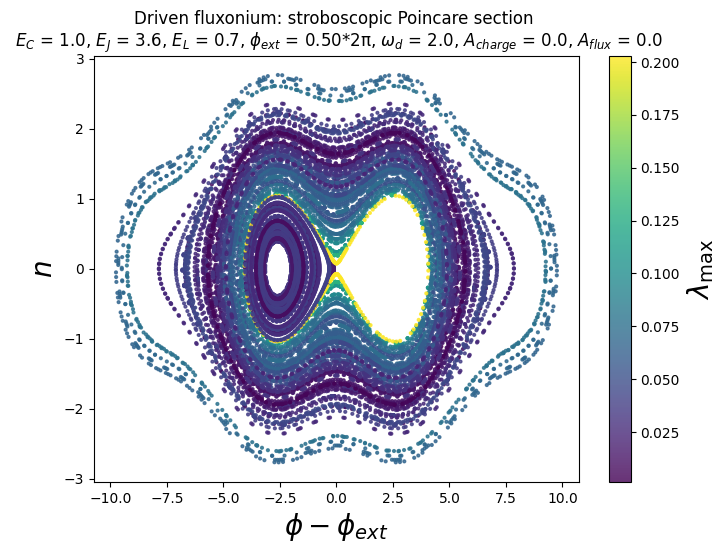

In [10]:
plt.figure(figsize=(7.0, 5.2))
plot_fontsize = 20

sc = plt.scatter(
    points[:, 0] - np.pi,
    points[:, 1],
    c=lambda_colors,
    cmap="viridis",
    s=4,
    alpha=0.8,
    rasterized=True,
)

plt.xlabel(r"$\phi - \phi_{ext}$", fontsize = plot_fontsize)
plt.ylabel(r"$n$", fontsize = plot_fontsize)
plt.tight_layout()

plt.title("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π, " \
""rf"$\omega_d$ = {param.omega_d}, $A_{{charge}}$ = {param.A_charge}, $A_{{flux}}$ = {param.A_flux}")

cbar = plt.colorbar(sc)
cbar.set_label(r"$\lambda_{\max}$", fontsize = plot_fontsize)

plt.show()

## Testing convergence for the Lyapunov

C:\Users\edson\AppData\Local\Temp\ipykernel_32980\1154202213.py:9: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
c:\Users\edson\Desktop\Research\Fluxonium chaos\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


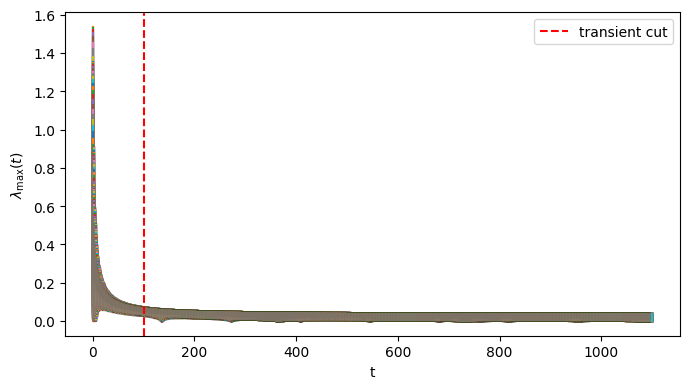

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(result["times"], result["lam_max_t"])
plt.axvline(result["stop_time"], color='red', ls='--', label='stop')
plt.xlabel("t")
plt.ylabel(r"$\lambda_{\max}(t)$")
plt.legend()
plt.tight_layout()
plt.show()

## Multiple plots for Driven system, changing drive frequency

In [2]:
import sys
sys.path.append('../src')  # add the src directory to the Python path


try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

from fluxonium_classical import (
    poincare_section,
    lyapunov_until_converged,
)

def poincare_with_lyapunov(
    p,
    initial_conditions,
    *,
    n_discard=0,
    n_strobes=200,
    phase_fraction=0.0,
    wrap_phi_for_plot=False,
    method="DOP853",
    rtol=1e-8,
    atol=1e-8,
    dt=1e-2,
    max_time=1000.0,
    min_time=100.0,
    window_time=20.0,
    std_tol=1e-2,
    drift_tol=1e-1,
    consecutive_windows=3,
    tangent_method="expm",
):
    all_points = []
    all_colors = []
    lambda_per_traj = []
    not_converged_indices = []

    initial_conditions = np.asarray(initial_conditions, dtype=float)

    progress = tqdm(
        enumerate(initial_conditions),
        total=len(initial_conditions),
        desc="Initial conditions",
        unit="IC",
    )

    for idx, u0 in progress:
        if hasattr(progress, "set_postfix"):
            progress.set_postfix(index=idx)

        pts = poincare_section(
            p=p,
            initial_conditions=np.array([u0]),
            n_discard=n_discard,
            n_strobes=n_strobes,
            phase_fraction=phase_fraction,
            wrap_phi_for_plot=wrap_phi_for_plot,
            method=method,
            rtol=rtol,
            atol=atol,
        )

        result = lyapunov_until_converged(
            u0=np.asarray(u0, dtype=float),
            p=p,
            dt=dt,
            max_time=max_time,
            min_time=min_time,
            window_time=window_time,
            std_tol=std_tol,
            drift_tol=drift_tol,
            consecutive_windows=consecutive_windows,
            tangent_method=tangent_method,
        )

        if not result["converged"]:
            not_converged_indices.append(idx)
            print(f"IC index {idx} did not converge: u0 = {u0}")

        color_vals = np.full(len(pts), result["lam_max"])

        all_points.append(pts)
        all_colors.append(color_vals)
        lambda_per_traj.append(result["lam_max"])

    all_points = np.vstack(all_points)
    all_colors = np.concatenate(all_colors)
    lambda_per_traj = np.array(lambda_per_traj)

    if not_converged_indices:
        print("Not converged IC indices:", not_converged_indices)

    return all_points, all_colors, lambda_per_traj


In [3]:
from fluxonium_classical import (
    FluxoniumParams,
    make_initial_conditions
)

omega_ds = [0.1, 1., 2., 3.0]
all_points_s = []
all_colors_s = []
lambda_per_traj_s = []

for omega_d in omega_ds:
    param = FluxoniumParams(
        EC=1.0,
        EJ=3.6,
        EL=0.7,
        phi_ext0= 0.5*2*np.pi,
        omega_d=omega_d,
        A_charge=0.1,
        A_flux=0.0,
    )
    display(param)
    # Initial conditions:
    ics = make_initial_conditions(
        phi_min=-2*np.pi,
        phi_max= 2*np.pi,
        n_min=-2.0,
        n_max= 2.0,
        n_phi=10,
        n_n=10,
        #random=True,
        #seed=4,
    )

    # Poincare section at phase_fraction = 0.0
    all_points, all_colors, lambda_per_traj = poincare_with_lyapunov(
        p=param,
        initial_conditions=ics,
    )
    all_points_s.append(all_points)
    all_colors_s.append(all_colors)
    lambda_per_traj_s.append(lambda_per_traj)



FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=0.1, A_charge=0.1, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=1.0, A_charge=0.1, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=2.0, A_charge=0.1, A_flux=0.0, gauge='inductive')

FluxoniumParams(EC=1.0, EJ=3.6, EL=0.7, phi_ext0=3.141592653589793, omega_d=3.0, A_charge=0.1, A_flux=0.0, gauge='inductive')

In [8]:
import h5py
import os
saving = False

import sys
sys.path.append('../src')  # add the src directory to the Python path

from fluxonium_classical import (
    FluxoniumParams,
)

omega_ds = [0.1, 1., 2., 3.0]
param = FluxoniumParams(
        EC=1.0,
        EJ=3.6,
        EL=0.7,
        phi_ext0= 0.5*2*np.pi,
        omega_d=0.0,
        A_charge=0.1,
        A_flux=0.0,
    )

if saving:
    # Create data directory if it doesn't exist
    os.makedirs('../data/Classical_Poincare_Lyapunov', exist_ok=True)

    # ============ SAVE ============
    # Generate filename with parameters
    filename = f'Classical_Lyapunov_EC={param.EC}_EJ={param.EJ}_EL={param.EL}_phi_ext={param.phi_ext0/(2*np.pi):.2f}_A_charge={param.A_charge}_A_flux={param.A_flux}.h5'
    filepath = f'../data/Classical_Poincare_Lyapunov/{filename}'

    with h5py.File(filepath, 'w') as f:    
        for i, (pts, cols, lam) in enumerate(zip(all_points_s, all_colors_s, lambda_per_traj_s)):
            group = f.create_group(f'omega_d_{i}')
            group.create_dataset('points', data=pts, compression='gzip', compression_opts=9)
            group.create_dataset('colors', data=cols, compression='gzip', compression_opts=9)
            group.create_dataset('lambda', data=np.array(lam), compression='gzip', compression_opts=9)
        
        # Save the omega_ds list as metadata
        f.create_dataset('omega_ds', data=omega_ds)


    print(f"Data saved to {filepath}")

else:
    # ============ LOAD ============
    filepath = f'../data/Classical_Poincare_Lyapunov/Classical_Lyapunov_EC={param.EC}_EJ={param.EJ}_EL={param.EL}_phi_ext={param.phi_ext0/(2*np.pi):.2f}_A_charge={param.A_charge}_A_flux={param.A_flux}.h5'

    with h5py.File(filepath, 'r') as f:
        # Load omega_ds
        omega_ds = f['omega_ds'][:]
        
        # Load all data for each omega_d
        all_points_s = []
        all_colors_s = []
        lambda_per_traj_s = []
        
        for i in range(len(omega_ds)):
            group = f[f'omega_d_{i}']
            all_points_s.append(group['points'][:])
            all_colors_s.append(group['colors'][:])
            lambda_per_traj_s.append(group['lambda'][:])

    print(f"Data loaded from {filepath}")
    print(f"omega_ds: {omega_ds}")

Data loaded from ../data/Classical_Poincare_Lyapunov/Classical_Lyapunov_EC=1.0_EJ=3.6_EL=0.7_phi_ext=0.50_A_charge=0.1_A_flux=0.0.h5
omega_ds: [0.1 1.  2.  3. ]


<>:29: SyntaxWarning: invalid escape sequence '\o'
<>:29: SyntaxWarning: invalid escape sequence '\o'
C:\Users\edson\AppData\Local\Temp\ipykernel_16996\2409896586.py:29: SyntaxWarning: invalid escape sequence '\o'
  axes[i].set_title(f"$\omega_{{d}}$ = {omega_d}", fontsize=plot_fontsize)


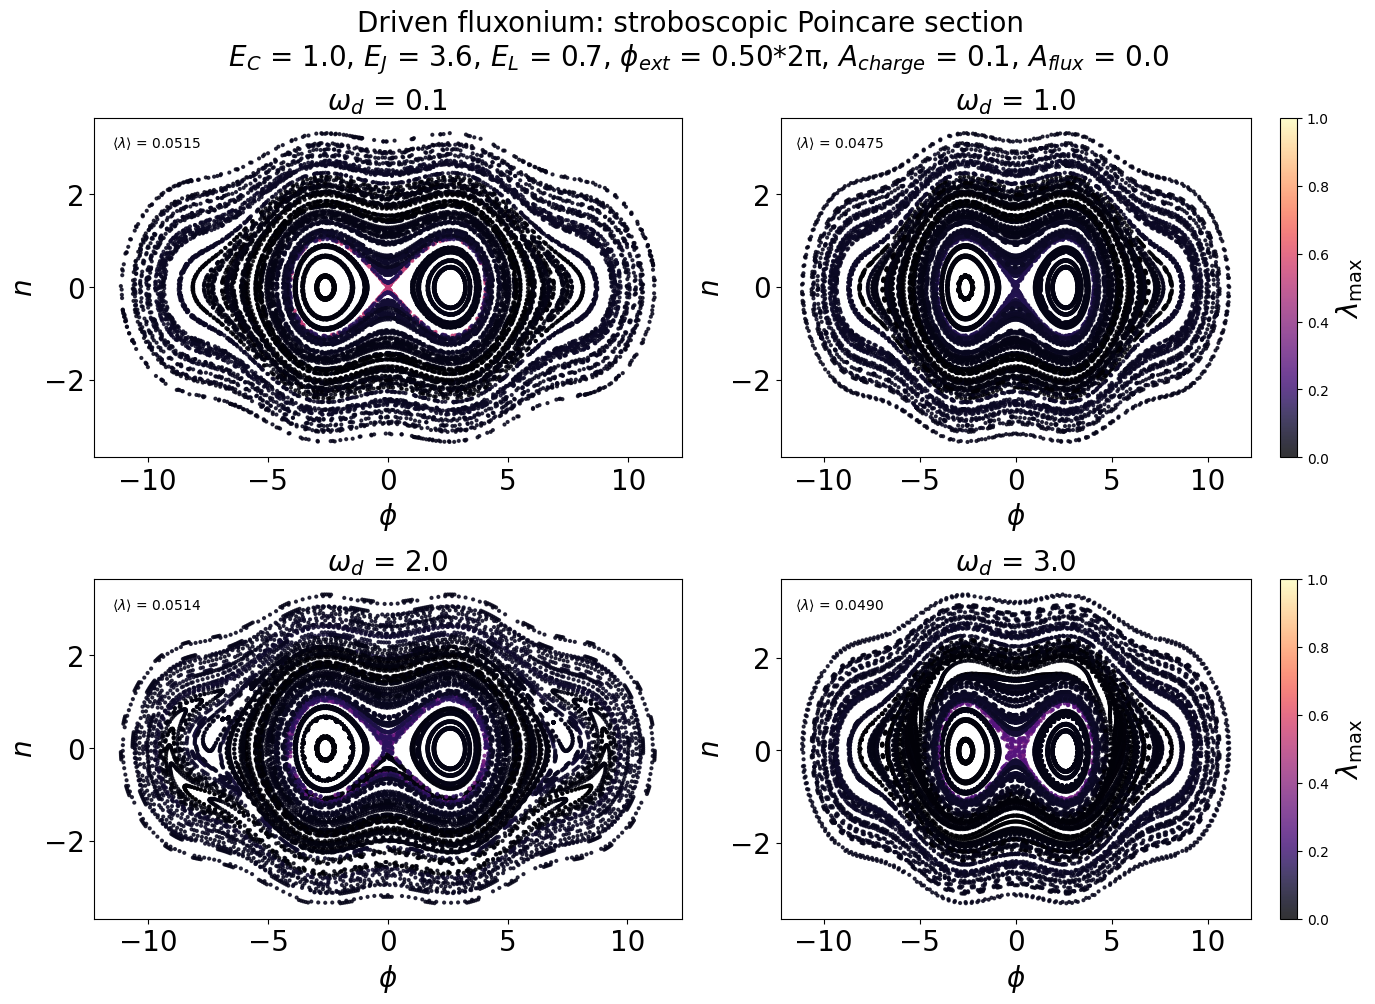

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.2))
axes = axes.flatten()  # flatten to iterate easily
plot_fontsize = 20


for i, omega_d in enumerate(omega_ds):
    points = all_points_s[i]
    lambdas = lambda_per_traj_s[i]
    sc = axes[i].scatter(
        points[:, 0] - np.pi,
        points[:, 1],
        c=all_colors_s[i],
        cmap="magma",
        s=4,
        alpha=0.8,
        rasterized=True,
        vmin = 0,
        vmax = 1.0
    )
    axes[i].text(
        0.03, 0.95,
        rf'$\langle \lambda \rangle$ = {np.mean(lambdas):.4f}',
        transform=axes[i].transAxes,
        ha='left',
        va='top'
    )
    axes[i].set_xlabel(r"$\phi$", fontsize=plot_fontsize)
    axes[i].set_ylabel(r"$n$", fontsize=plot_fontsize)
    axes[i].set_title(f"$\omega_{{d}}$ = {omega_d}", fontsize=plot_fontsize)
    axes[i].tick_params(axis='both', labelsize=plot_fontsize)
    if ((i+1) % 2) == 0:
        cbar = plt.colorbar(sc)
        cbar.set_label(r"$\lambda_{\max}$", fontsize = plot_fontsize)


fig.suptitle("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π, " \
""rf"$A_{{charge}}$ = {param.A_charge}, $A_{{flux}}$ = {param.A_flux}", fontsize=plot_fontsize)
plt.tight_layout()
plt.show()

## Multiple plots for Driven system, changing drive amplitude

In [ ]:
import sys
sys.path.append('../src')  # add the src directory to the Python path


try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(iterable, **kwargs):
        return iterable

from fluxonium_classical import (
    poincare_section,
    lyapunov_until_converged,
)

def poincare_with_lyapunov(
    p,
    initial_conditions,
    *,
    n_discard=0,
    n_strobes=200,
    phase_fraction=0.0,
    wrap_phi_for_plot=False,
    method="DOP853",
    rtol=1e-8,
    atol=1e-8,
    dt=1e-2,
    max_time=1000.0,
    min_time=100.0,
    window_time=20.0,
    std_tol=1e-2,
    drift_tol=1e-1,
    consecutive_windows=3,
    tangent_method="expm",
    ):
    all_points = []
    all_colors = []
    lambda_per_traj = []
    not_converged_indices = []
    initial_conditions = np.asarray(initial_conditions, dtype=float)

    progress = tqdm(
        enumerate(initial_conditions),
        total=len(initial_conditions),
        desc="Initial conditions",
        unit="IC",
    )
    
    for idx, u0 in progress:
        if hasattr(progress, "set_postfix"):
            progress.set_postfix(index=idx)

        pts = poincare_section(
            p=p,
            initial_conditions=np.array([u0]),
            n_discard=n_discard,
            n_strobes=n_strobes,
            phase_fraction=phase_fraction,
            wrap_phi_for_plot=wrap_phi_for_plot,
            method=method,
            rtol=rtol,
            atol=atol,
        )

        result = lyapunov_until_converged(
            u0=np.asarray(u0, dtype=float),
            p=p,
            dt=dt,
            max_time=max_time,
            min_time=min_time,
            window_time=window_time,
            std_tol=std_tol,
            drift_tol=drift_tol,
            consecutive_windows=consecutive_windows,
            tangent_method=tangent_method,
        )
        
        if not result["converged"]:
            not_converged_indices.append(idx)
            print(f"IC index {idx} did not converge: u0 = {u0}")

        color_vals = np.full(len(pts), result["lam_max"])

        all_points.append(pts)
        all_colors.append(color_vals)
        lambda_per_traj.append(result["lam_max"])

    all_points = np.vstack(all_points)
    all_colors = np.concatenate(all_colors)
    lambda_per_traj = np.array(lambda_per_traj)

    if not_converged_indices:
        print("Not converged IC indices:", not_converged_indices)

    return all_points, all_colors, lambda_per_traj

In [14]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, poincare_section, make_initial_conditions

A_charges = [0.0, 0.01, 0.05, 0.1]
pointss = []
all_points_s = []
all_colors_s = []
lambda_per_traj_s = []

for A_charge in A_charges:
    param = FluxoniumParams(
        EC=1.0,
        EJ=3.6,
        EL=0.7,
        phi_ext0= 0.5*2*np.pi,
        omega_d=2.0,
        A_charge=A_charge,
        A_flux=0.0,
    )
    #display(param)
    # Initial conditions:
    ics = make_initial_conditions(
        phi_min=-2*np.pi,
        phi_max= 2*np.pi,
        n_min=-2.0,
        n_max= 2.0,
        n_phi=10,
        n_n=10,
        #random=True,
        #seed=4,
    )

    # Poincare section at phase_fraction = 0.0
    all_points, all_colors, lambda_per_traj = poincare_with_lyapunov(
        p=param,
        initial_conditions=ics,
    )
    all_points_s.append(all_points)
    all_colors_s.append(all_colors)
    lambda_per_traj_s.append(lambda_per_traj)

KeyboardInterrupt: 

In [ ]:
import h5py
import os
saving = True

import sys
sys.path.append('../src')  # add the src directory to the Python path

from fluxonium_classical import (
    FluxoniumParams,
)

A_charges = [0.0, 0.01, 0.05, 0.1]
param = FluxoniumParams(
        EC=1.0,
        EJ=3.6,
        EL=0.7,
        phi_ext0= 0.5*2*np.pi,
        omega_d=2.0,
        A_charge=0.1,
        A_flux=0.0,
    )

if saving:
    # Create data directory if it doesn't exist
    os.makedirs('../data/Classical_Poincare_Lyapunov', exist_ok=True)

    # ============ SAVE ============
    # Generate filename with parameters
    filename = f'Classical_Lyapunov_EC={param.EC}_EJ={param.EJ}_EL={param.EL}_phi_ext={param.phi_ext0/(2*np.pi):.2f}_omega_d={param.omega_d}_A_flux={param.A_flux}.h5'
    filepath = f'../data/Classical_Poincare_Lyapunov/{filename}'

    with h5py.File(filepath, 'w') as f:    
        for i, (pts, cols, lam) in enumerate(zip(all_points_s, all_colors_s, lambda_per_traj_s)):
            group = f.create_group(f'A_charge_{i}')
            group.create_dataset('points', data=pts, compression='gzip', compression_opts=9)
            group.create_dataset('colors', data=cols, compression='gzip', compression_opts=9)
            group.create_dataset('lambda', data=np.array(lam), compression='gzip', compression_opts=9)
        
        # Save the A_charges list as metadata
        f.create_dataset('A_charges', data=A_charges)


    print(f"Data saved to {filepath}")

else:
    # ============ LOAD ============
    filepath = f'../data/Classical_Poincare_Lyapunov/Classical_Lyapunov_EC={param.EC}_EJ={param.EJ}_EL={param.EL}_phi_ext={param.phi_ext0/(2*np.pi):.2f}_omega_d={param.omega_d}_A_flux={param.A_flux}.h5'

    with h5py.File(filepath, 'r') as f:
        # Load A_charges
        A_charges = f['A_charges'][:]
        
        # Load all data for each omega_d
        all_points_s = []
        all_colors_s = []
        lambda_per_traj_s = []
        
        for i in range(len(A_charges)):
            group = f[f'A_charge_{i}']
            all_points_s.append(group['points'][:])
            all_colors_s.append(group['colors'][:])
            lambda_per_traj_s.append(group['lambda'][:])

    print(f"Data loaded from {filepath}")
    print(f"A_charges: {A_charges}")

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.2))
axes = axes.flatten()  # flatten to iterate easily
plot_fontsize = 20


for i, A_charge in enumerate(A_charges):
    points = all_points[i]
    lambdas = lambda_per_traj_s[i]
    sc = axes[i].scatter(
        points[:, 0] - np.pi,
        points[:, 1],
        c=all_colors_s[i],
        cmap="viridis",
        s=4,
        alpha=0.8,
        rasterized=True,
        vmin = 0,
        vmax = 1.0
    )
    axes[i].text(
        0.03, 0.95,
        rf'$\langle \lambda \rangle$ = {np.mean(lambdas):.4f}',
        transform=axes[i].transAxes,
        ha='left',
        va='top'
    )
    axes[i].set_xlabel(r"$\phi$", fontsize=plot_fontsize)
    axes[i].set_ylabel(r"$n$", fontsize=plot_fontsize)
    axes[i].set_title(f"$A_{{charge}}$ = {A_charge}", fontsize=plot_fontsize)
    axes[i].tick_params(axis='both', labelsize=plot_fontsize)
    if ((i+1) % 2) == 0:
        cbar = plt.colorbar(sc)
        cbar.set_label(r"$\lambda_{\max}$", fontsize = plot_fontsize)


fig.suptitle("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π, " \
""rf"$\omega_{{d}}$ = {param.omega_d}, $A_{{flux}}$ = {param.A_flux}", fontsize=plot_fontsize)
plt.tight_layout()
plt.show()

In [ ]:
import sys
sys.path.append('../src')  # add the src directory to the Python path
from fluxonium_classical import FluxoniumParams, poincare_section, make_initial_conditions

A_charges = [0.1, 0.5, 1.0, 5.0]
pointss = []
all_points_s = []
all_colors_s = []
lambda_per_traj_s = []

for A_charge in A_charges:
    param = FluxoniumParams(
        EC=1.0,
        EJ=3.6,
        EL=0.7,
        phi_ext0= 0.5*2*np.pi,
        omega_d=2.0,
        A_charge=A_charge,
        A_flux=0.0,
    )
    #display(param)
    # Initial conditions:
    ics = make_initial_conditions(
        phi_min=-2*np.pi,
        phi_max= 2*np.pi,
        n_min=-2.0,
        n_max= 2.0,
        n_phi=10,
        n_n=10,
        #random=True,
        #seed=4,
    )

    # Poincare section at phase_fraction = 0.0
    all_points, all_colors, lambda_per_traj = poincare_with_lyapunov(
        p=param,
        initial_conditions=ics,
    )
    all_points_s.append(all_points)
    all_colors_s.append(all_colors)
    lambda_per_traj_s.append(lambda_per_traj)

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14.0, 10.2))
axes = axes.flatten()  # flatten to iterate easily
plot_fontsize = 20


for i, A_charge in enumerate(A_charges):
    points = all_points[i]
    lambdas = lambda_per_traj_s[i]
    sc = axes[i].scatter(
        points[:, 0] - np.pi,
        points[:, 1],
        c=all_colors_s[i],
        cmap="viridis",
        s=4,
        alpha=0.8,
        rasterized=True,
        vmin = 0,
        vmax = 1.0
    )
    axes[i].text(
        0.03, 0.95,
        rf'$\langle \lambda \rangle$ = {np.mean(lambdas):.4f}',
        transform=axes[i].transAxes,
        ha='left',
        va='top'
    )
    axes[i].set_xlabel(r"$\phi$", fontsize=plot_fontsize)
    axes[i].set_ylabel(r"$n$", fontsize=plot_fontsize)
    axes[i].set_title(f"$A_{{charge}}$ = {A_charge}", fontsize=plot_fontsize)
    axes[i].tick_params(axis='both', labelsize=plot_fontsize)
    if ((i+1) % 2) == 0:
        cbar = plt.colorbar(sc)
        cbar.set_label(r"$\lambda_{\max}$", fontsize = plot_fontsize)


fig.suptitle("Driven fluxonium: stroboscopic Poincare section \n " \
""rf"$E_C$ = {param.EC}, $E_J$ = {param.EJ}, $E_L$ = {param.EL}, $\phi_{{ext}}$ = {param.phi_ext0/ (2*np.pi):.2f}*2π, " \
""rf"$\omega_{{d}}$ = {param.omega_d}, $A_{{flux}}$ = {param.A_flux}", fontsize=plot_fontsize)
plt.tight_layout()
plt.show()